#XRD Data from Dr Katherine Page

In [1]:
!gdown --fuzzy https://drive.google.com/file/d/1Zzknr5yjvzTgPCMY7PD4YjcRJoecBK8z/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1Zzknr5yjvzTgPCMY7PD4YjcRJoecBK8z
To: /content/Data for Hackathon.zip
100% 937k/937k [00:00<00:00, 62.7MB/s]


In [2]:
!unzip '/content/Data for Hackathon.zip'

Archive:  /content/Data for Hackathon.zip
   creating: Data for Hackathon/
   creating: Data for Hackathon/Cifs/
  inflating: Data for Hackathon/Cifs/Gadolinium Titanate Pyro.cif  
  inflating: Data for Hackathon/Cifs/Hybrid HE Ti Pyro.cif  
  inflating: Data for Hackathon/Info.txt  
   creating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I11_175°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I14_225°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I17_275°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I20_325°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I23_375°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I26_425°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I29_475°C.xrdml  
  inflating: Data for Hackathon/PrNdGdYbLu2 Ti2 O7/PrNdGdYbLu_I2_25°C.xrdml  
  inflating: Data for Hac

In [3]:
import os, textwrap

BASE = "/content/Data for Hackathon"
for d in sorted(os.listdir(BASE)):
    p = os.path.join(BASE, d)
    mark = "📁" if os.path.isdir(p) else "📄"
    print(f"{mark} {d}")


📁 Cifs
📄 Info.txt
📁 PrNdGdYbLu2 Ti2 O7
📁 PrSmGdHoLu2 Ti2 O7
📁 SmEuGdTbDy2 Ti2 O7
📁 Standard Data


###  Accessing and Exploring the XRD Data

Each folder inside `/content/Data` contains XRD scans for a different material:

```
/content/Data
 ├── PrNdGdYbLu2 Ti2 O7/
 ├── PrSmGdHoLu2 Ti2 O7/
 ├── SmEuGdTbDy2 Ti2 O7/
 ├── Standard Data/
 └── Cifs/   ← structure models for fitting
```

#### 🧩 What you need to do

1. **Preview the data** – load and plot an XRD pattern from one of the sample folders.
2. **Compare patterns** – look at how the peaks shift between different samples.
3. **Use the CIFs** – later, you can use the `.cif` files in `/content/Data/Cifs` for model fitting (for example, in DARA).

#### 🧠 Steps

1. Run the next cell to define a **small function** that reads `.xrdml` files (the standard PANalytical format).
2. Change the folder name (for example, to `"SmEuGdTbDy2 Ti2 O7"`) and **run the next cell** to:

   * Plot one scan from that folder.
   * Optionally compare the first scan from all sample folders.

#### ⚙️ Notes

* The `Standard Data` folder is a **reference pattern** — use it to refine or fix your instrument parameters before fitting complex samples..
* Once you verify the data loads correctly, you can move to the **DARA refinement notebook** and use these same blocks to code there to load data in there.

In [4]:
from IPython.display import Markdown

path = "/content/Data for Hackathon/Info.txt"
with open(path) as f:
    content = f.read()

display(Markdown(f"### ℹ️ Dataset Information\n\n{content}"))


### ℹ️ Dataset Information

The raw X-Ray diffraction data are in the folders labelled by each sample name. Each file has the temperature that the measurement was taken at. For each a series of scans from 25-1175 C was taken at 50 C intervals.

A measured silicon standard is provided which can be used for making an instrument parameter file.

For Samples the compositions are as follows

Sm 2/5 Eu 2/5 Gd 2/5 Tb 2/5 Dy 2/5 Ti 2 O 7

Pr 2/5 Sm 2/5 Gd 2/5 Ho 2/5 Lu 2/5 Ti 2 O 7

Pr 2/5 Nd 2/5 Gd 2/5 Yb 2/5 Lu 2/5 Ti 2 O 7

For the cifs that were provided there is Gadolinium Titanate which can act as a baseline for adding elements and a Hybrid High Entropy Structure that has all the elements added into it as well as a degree of site inversion added in between the rare earth elements and the titanium.

In [6]:
# Minimal XRDML -> DataFrame
import xml.etree.ElementTree as ET, numpy as np, pandas as pd

def read_xrdml_df(path, scan_index=0):
    r = ET.parse(path).getroot(); ns = {"x": r.tag.split('}')[0].strip('{')}
    # prefer dataPoints blocks
    dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)
    if dp is None: raise ValueError("No dataPoints found")
    ints = (dp.findtext("x:intensities", namespaces=ns)
            or dp.findtext("x:counts", namespaces=ns) or "").strip()
    I = np.fromstring(ints, sep=' ')
    pos = dp.find("x:positions", ns)
    if pos is not None:
        s = pos.findtext("x:startPosition", namespaces=ns); e = pos.findtext("x:endPosition", namespaces=ns)
        if s and e: x = np.linspace(float(s), float(e), I.size)
        else:
            txt = (pos.text or "").strip(); x = np.fromstring(txt, sep=' ') if txt else None
    else:
        s = dp.findtext("x:startPosition", namespaces=ns); e = dp.findtext("x:endPosition", namespaces=ns)
        x = np.linspace(float(s), float(e), I.size) if s and e else None
    if x is None or I.size != x.size: raise ValueError("Could not reconstruct 2θ")
    return pd.DataFrame({"2theta_deg": x, "intensity": I})


/tmp/ipython-input-1535819371.py:7: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)


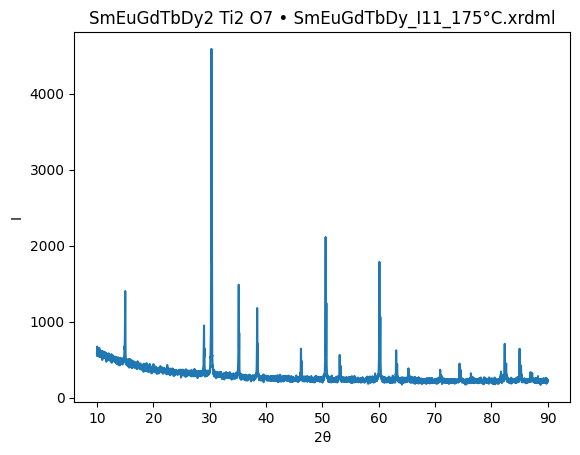

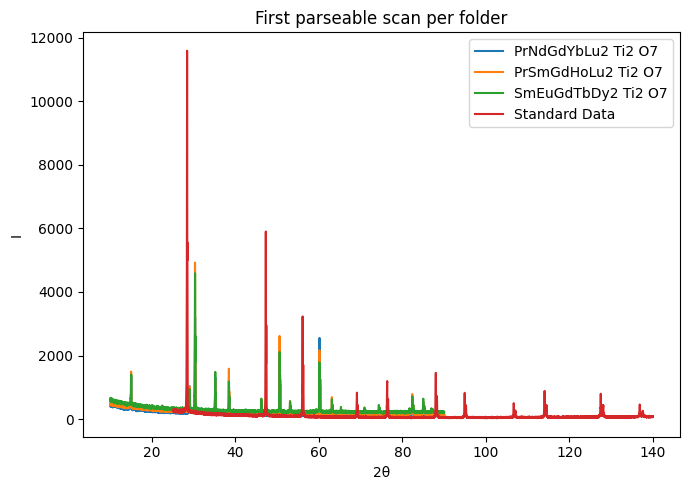

In [7]:
import os, matplotlib.pyplot as plt

BASE = "/content/Data for Hackathon"
SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

# --- A) Preview ONE folder (change the name below) ---
FOLDER = "SmEuGdTbDy2 Ti2 O7"
p = os.path.join(BASE, FOLDER)
f = next((fn for fn in sorted(os.listdir(p)) if fn.lower().endswith(".xrdml")), None)
df = read_xrdml_df(os.path.join(p, f))
plt.plot(df["2theta_deg"], df["intensity"]); plt.xlabel("2θ"); plt.ylabel("I"); plt.title(f"{FOLDER} • {f}"); plt.show()

# --- B) Quick compare (first parseable file from each folder) ---
plt.figure(figsize=(7,5))
for name in SAMPLE_FOLDERS:
    q = os.path.join(BASE, name)
    files = [fn for fn in sorted(os.listdir(q)) if fn.lower().endswith(".xrdml")]
    for fn in files:
        try:
            df = read_xrdml_df(os.path.join(q, fn)); plt.plot(df["2theta_deg"], df["intensity"], label=name); break
        except Exception:
            continue
plt.xlabel("2θ"); plt.ylabel("I"); plt.title("First parseable scan per folder"); plt.legend(); plt.tight_layout(); plt.show()


# XRD data from Dr Claudia Rawn

In [8]:
!gdown --fuzzy https://drive.google.com/file/d/1RP9hezq8hVuTuPj-_Qy9zvbSDTSgHw7E/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1RP9hezq8hVuTuPj-_Qy9zvbSDTSgHw7E
To: /content/XRD Data for CAMM hackathon_Rawn.zip
100% 40.7k/40.7k [00:00<00:00, 71.8MB/s]


In [9]:
!unzip '/content/XRD Data for CAMM hackathon_Rawn.zip' -d /content/XRD_Hackathon_Rawn

Archive:  /content/XRD Data for CAMM hackathon_Rawn.zip
  inflating: /content/XRD_Hackathon_Rawn/(YPrNdHoTm)3Al5O12 PSE.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Al2O3 30024.cif  
  inflating: /content/XRD_Hackathon_Rawn/Tb3Al5O12 PSE.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Y3Al5O12 PSE.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Y3Al5O12 SSR.xrdml  
  inflating: /content/XRD_Hackathon_Rawn/Y3Al5O12 YAG 23848.cif  
  inflating: /content/XRD_Hackathon_Rawn/Y4Al2O9 YAM 63650 monoclinic P121c1.cif  
  inflating: /content/XRD_Hackathon_Rawn/YAlO3 YAP 27100 hexagonal P63mmc.cif  
  inflating: /content/XRD_Hackathon_Rawn/YAlO3 YAP 4115 orthorhombic Pnma.cif  
  inflating: /content/XRD_Hackathon_Rawn/ZrO2 89429.cif  


In [10]:
import os, textwrap

BASE = "/content/XRD_Hackathon_Rawn"
for d in sorted(os.listdir(BASE)):
    p = os.path.join(BASE, d)
    mark = "📁" if os.path.isdir(p) else "📄"
    print(f"{mark} {d}")


📄 (YPrNdHoTm)3Al5O12 PSE.xrdml
📄 Al2O3 30024.cif
📄 Tb3Al5O12 PSE.xrdml
📄 Y3Al5O12 PSE.xrdml
📄 Y3Al5O12 SSR.xrdml
📄 Y3Al5O12 YAG 23848.cif
📄 Y4Al2O9 YAM 63650 monoclinic P121c1.cif
📄 YAlO3 YAP 27100 hexagonal P63mmc.cif
📄 YAlO3 YAP 4115 orthorhombic Pnma.cif
📄 ZrO2 89429.cif


/tmp/ipython-input-1535819371.py:7: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)


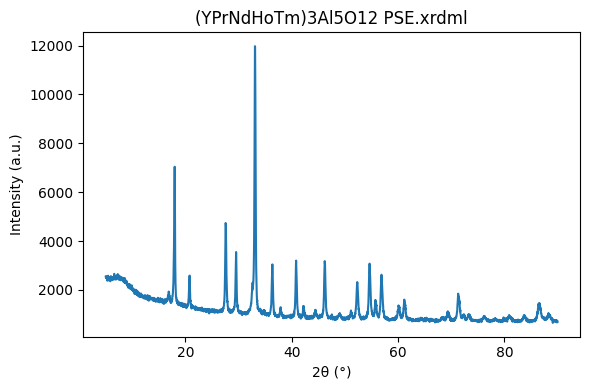

In [11]:
# --- Choose any .xrdml file from the folder ---
import matplotlib.pyplot as plt

file = "(YPrNdHoTm)3Al5O12 PSE.xrdml"  # 👈 change this
df = read_xrdml_df(os.path.join(BASE, file))

plt.figure(figsize=(6,4))
plt.plot(df["2theta_deg"], df["intensity"])
plt.xlabel("2θ (°)")
plt.ylabel("Intensity (a.u.)")
plt.title(file)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1535819371.py:7: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)


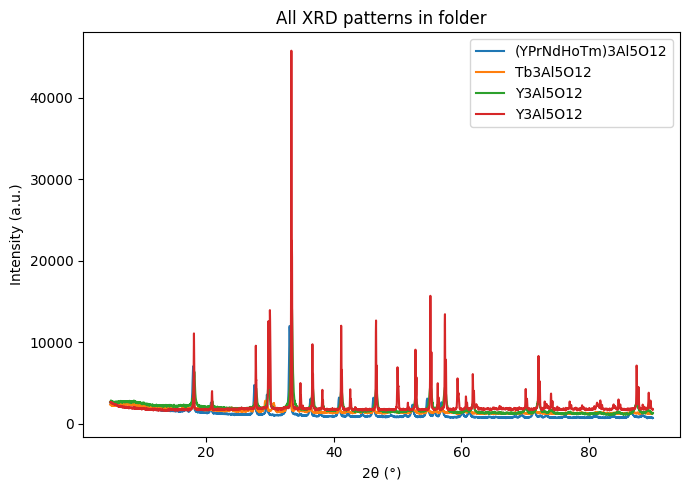

In [12]:
plt.figure(figsize=(7,5))
for f in sorted(os.listdir(BASE)):
    if f.lower().endswith(".xrdml"):
        try:
            df = read_xrdml_df(os.path.join(BASE, f))
            plt.plot(df["2theta_deg"], df["intensity"], label=f.split()[0])
        except Exception:
            continue
plt.xlabel("2θ (°)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.title("All XRD patterns in folder")
plt.tight_layout()
plt.show()


# CIF file info
To get some info on the .cif file, use the code below

In [13]:
file = "/content/XRD_Hackathon_Rawn/Al2O3 30024.cif"  # 👈 change this
with open(os.path.join(BASE, file)) as f:
    print(f.read()[:400], "...")



#(C) 2023 by FIZ Karlsruhe - Leibniz Institute for Information Infrastructure.  All rights reserved.
data_30024-ICSD
_database_code_ICSD 30024
_audit_creation_date 1980-01-01
_audit_update_record 2007-08-01
_chemical_name_common 'Aluminium oxide - Cr-doped'
_chemical_formula_structural 'Al2 O3'
_chemical_formula_sum 'Al2 O3'
_chemical_name_structure_type Corundum#Al2O3
_exptl_crystal_density_diff ...


# Hackathon Day 4

## Refinement

So, all I want to accomplish from today is to learn how to analyze the XRay data using DARA. If this works, I may be able to use these systems for the active learning in the loop on the combi libraries.

In [14]:
%pip install ipywidgets nbformat
!pip install dara-xrd
!pip install kaleido==0.2.1 # Install a compatible version of kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.0/642.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.1/107.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.9/577.9 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 44.9 MB/s eta 0:00:00
   ━━━━

In [15]:
!git clone https://github.com/idocx/dara.git # Sample data from DARA repository
!mv dara/notebooks/tutorial_data .
!rm -rf dara

Cloning into 'dara'...
remote: Enumerating objects: 6278, done.
remote: Counting objects: 100% (546/546), done.
remote: Compressing objects: 100% (220/220), done.
remote: Total 6278 (delta 460), reused 365 (delta 323), pack-reused 5732 (from 3)
Receiving objects: 100% (6278/6278), 123.87 MiB | 8.54 MiB/s, done.
Resolving deltas: 100% (3218/3218), done.


In [17]:
from pathlib import Path
from dara.refine import do_refinement_no_saving

In [27]:
data = Path("tutorial_data")
cif_paths = list(data.glob("*.cif"))  # include all the cif files in the data folder

pattern_fn = "CaNi(PO3)4_800_240_Ca(OH)2_(NH4)2HPO4_NiO.xy"

In [19]:
refinement = do_refinement_no_saving(data / pattern_fn, cif_paths)

2025-11-07 20:01:43,975 WARNING dara.bgmn_worker BGMN executable not found. Downloading BGMN.


100%|██████████| 1.59M/1.59M [00:00<00:00, 4.84MiB/s]


In [20]:
refinement.visualize()

Now. let's try it for the Claudia data

Let's see how I can get the .xy file from the .xrdml file. Presumably it will be /xy file?

- xrdtools does not work for the latest Panalytical data format.
- So we choose a xrayutilities

In [ ]:
!pip -q install xrayutilities
from xrayutilities.io import XRDMLFile

In [32]:
xr = XRDMLFile("/content/XRD_Hackathon_Rawn/Y3Al5O12 PSE.xrdml")
two_theta = xr.scan.scanmot   # scan axis (e.g., 2Theta)
intensity = xr.scan.int       # counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 6.2 MB/s eta 0:00:00


In [33]:
plt.plot(two_theta, intensity)

array([64.02020931, 65.4637315 , 64.45326597, ..., 30.81919885,
       29.47191146, 31.05978588])

In [34]:
# two_theta and intensity are 1D NumPy arrays of equal length
x = np.asarray(two_theta).ravel()
y = np.asarray(intensity).ravel()

# Optional: clean + sort (recommended)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]
order = np.argsort(x)
x, y = x[order], y[order]

# Save as tab-separated .xy
out_path = "/content/XRD_Hackathon_Rawn/pattern.xy"  # change path/name as you like
np.savetxt(out_path, np.column_stack([x, y]),
           fmt=['%.8f', '%.1f'],   # x with 8 decimals, y with 1 decimal (e.g., 3333.0)
           delimiter='\t')

print("Wrote:", out_path)

Wrote: /content/XRD_Hackathon_Rawn/pattern.xy


In [37]:
data = Path("/content/XRD_Hackathon_Rawn")
cif_paths = list(data.glob("*.cif"))  # include all the cif files in the data folder

pattern_fn = "pattern.xy"

In [38]:
refinement1 = do_refinement_no_saving(data / pattern_fn, cif_paths)

Comment: this takes about 5 minutes

In [39]:
refinement1.visualize()

In [40]:
refinement1.visualize().write_html("tutorial_refinement.html")  # output the interactive html file to the disk
refinement1.visualize().write_image("tutorial_refinement.png")  # output the png image to the disk

In [44]:
refinement1.lst_data

LstResult(raw_lst='Rietveld refinement to file(s) pattern.xy\nBGMN version 4.2.23, 3237 measured points, 879 peaks, 50 parameters\nStart: Fri Nov  7 20:23:23 2025; End: Fri Nov  7 20:28:56 2025\n537 iteration steps\n\nRp=3.20%  Rpb=6.28%  R=4.04%  Rwp=4.07% Rexp=14.47%\nDurbin-Watson d=0.82\n1-rho=1.39%\n\nGlobal parameters and GOALs\n****************************\nQY4Al2O9YAM63650monoclinicP121c1=0.103+-0.013\nQAl2O330024=0.434+-0.029\nQZrO289429=0.0025+-0.0048\nQYAlO3YAP4115orthorhombicPnma=0.236+-0.020\nQY3Al5O12YAG23848=0.224+-0.017\nQYAlO3YAP27100hexagonalP63mmc=0\nEPS2=-0.001315+-0.000053\n\nLocal parameters and GOALs for phase Y4Al2O9YAM63650monoclinicP121c1\n******************************************************\nSpacegroupNo=14\nHermannMauguin=P12_1/c1\nXrayDensity=3.741\nRphase=3.93%\nUNIT=NM\nA=0.788+-0.029\nB=1.029+-0.028\nC=1.22378\nBETA=97.6860\nk1=0.0100000\nk2=0.0100000\nB1=0.0100000\nGEWICHT=0.00269+-0.00038\nGrainSize(1,1,1)=42.0906\nAtomic positions for phase Y4Al2O9Y

Here I use ChatGPT to parse it. However, in principle I can use the inline GEMINI call to do it.

In [50]:
import re, math, json
import numpy as np
import pandas as pd

# ===== Helpers =====
def _to_float_or_nan(s):
    if s is None:
        return float("nan")
    s = str(s).strip()
    if s.upper() in {"UNDEF", "ERROR"}:
        return float("nan")
    try:
        return float(s)
    except Exception:
        return float("nan")

def _ensure_text(x):
    if isinstance(x, bytes):
        return x.decode("utf-8", "ignore")
    return str(x)

def extract_raw_lst(lst_like):
    """
    Accepts:
      - a raw .lst text, or
      - a repr-like string: LstResult(raw_lst='...\\n...').
    Returns raw .lst with real newlines.
    """
    s = _ensure_text(lst_like)

    # Try to extract the raw_lst='...'
    m = re.search(r"raw_lst='(.*)'[,)]", s, flags=re.S)
    if m:
        raw = m.group(1)
        # Unescape common sequences (the repr uses literal \n)
        # Do targeted replacements (safer than unicode_escape over arbitrary content).
        raw = raw.replace("\\r\\n", "\n").replace("\\n", "\n").replace("\\t", "\t")
        return raw

    # Otherwise assume s is already the raw LST text
    return s

def parse_global_metrics(raw):
    out = {}
    m = re.search(r"Rp=([-\d.]+)%\s+Rpb=([-\d.]+)%\s+R=([-\d.]+)%\s+Rwp=([-\d.]+)%\s+Rexp=([-\d.]+)%", raw)
    if m:
        out.update(dict(Rp=float(m.group(1)), Rpb=float(m.group(2)),
                        R=float(m.group(3)), Rwp=float(m.group(4)), Rexp=float(m.group(5))))
    m = re.search(r"Durbin-Watson d=([-\d.]+)", raw)
    if m: out["DurbinWatson_d"] = float(m.group(1))
    m = re.search(r"1-rho=([-\d.]+)%", raw)
    if m: out["one_minus_rho_percent"] = float(m.group(1))
    m = re.search(r"BGMN version.*?,\s*(\d+)\s*measured points,\s*(\d+)\s*peaks,\s*(\d+)\s*parameters", raw)
    if m:
        out.update(dict(n_points=int(m.group(1)), n_peaks=int(m.group(2)), n_params=int(m.group(3))))
    m = re.search(r"(\d+)\s+iteration steps", raw)
    if m: out["iteration_steps"] = int(m.group(1))
    m = re.search(r"Rietveld refinement to file\(s\)\s+([^\n]+)", raw)
    if m: out["pattern_name"] = m.group(1).strip()
    m = re.search(r"\bEPS2=([-\d.eE]+)(?:\+\-([-\d.eE]+))?", raw)
    if m:
        out["EPS2"] = float(m.group(1))
        out["dEPS2"] = float(m.group(2)) if m.group(2) else float("nan")
    return out

def parse_q_lines(raw):
    rows = []
    for m in re.finditer(r"^Q(\S+?)=([-\d.eE]+)(?:\+\-([-\d.eE]+))?$", raw, flags=re.M):
        phase_key = m.group(1)
        val = float(m.group(2))
        dval = float(m.group(3)) if m.group(3) else float("nan")
        rows.append(dict(phase_key=phase_key, Q=val, dQ=dval))
    df = pd.DataFrame(rows)
    if not df.empty:
        total = df["Q"].sum()
        df["Q_percent"] = 100.0 * df["Q"] / (total if total != 0 else 1.0)
        df["dQ_percent"] = 100.0 * df["dQ"]
    return df

def parse_phase_blocks(raw):
    rows = []
    it = re.finditer(
        r"Local parameters and GOALs for phase ([^\n]+)\n\*+\n(.*?)(?=\nLocal parameters and GOALs for phase |\Z)",
        raw, flags=re.S
    )
    for m in it:
        name = m.group(1).strip()
        block = m.group(2)

        def grab(pat):
            r = re.search(pat, block)
            return r.group(1) if r else None

        space_no = grab(r"SpacegroupNo=([-\d.]+)")
        hm = grab(r"HermannMauguin=([^\n]+)")
        dens = grab(r"XrayDensity=([-\d.]+)")
        rphase = grab(r"Rphase=([-\d.]+)%")
        unit = grab(r"UNIT=([A-Za-z]+)")

        a = grab(r"\nA=([^\n]+)")
        b = grab(r"\nB=([^\n]+)")
        c = grab(r"\nC=([^\n]+)")
        alpha = grab(r"\nALPHA=([^\n]+)")
        beta  = grab(r"\nBETA=([^\n]+)")
        gamma = grab(r"\nGAMMA=([^\n]+)")

        g = grab(r"\nGEWICHT=([^\n]+)")
        g_val, g_err = (math.nan, math.nan)
        if g is not None:
            if "+-" in g:
                g_val, g_err = [_to_float_or_nan(x) for x in g.split("+-", 1)]
            else:
                g_val = _to_float_or_nan(g)

        rows.append(dict(
            phase=name,
            spacegroup_no=_to_float_or_nan(space_no),
            hermann_mauguin=(hm.strip() if hm else None),
            xray_density=_to_float_or_nan(dens),
            rphase_percent=_to_float_or_nan(rphase),
            unit=(unit or None),
            a=_to_float_or_nan(a.split("+-")[0]) if a else math.nan,
            a_esd=_to_float_or_nan(a.split("+-")[1]) if (a and "+-" in a) else math.nan,
            b=_to_float_or_nan(b.split("+-")[0]) if b else math.nan,
            b_esd=_to_float_or_nan(b.split("+-")[1]) if (b and "+-" in b) else math.nan,
            c=_to_float_or_nan(c.split("+-")[0]) if c else math.nan,
            c_esd=_to_float_or_nan(c.split("+-")[1]) if (c and "+-" in c) else math.nan,
            alpha=_to_float_or_nan(alpha.split("+-")[0]) if alpha else math.nan,
            beta=_to_float_or_nan(beta.split("+-")[0]) if beta else math.nan,
            gamma=_to_float_or_nan(gamma.split("+-")[0]) if gamma else math.nan,
            gewicht=g_val,
            dgewicht=g_err
        ))
    return pd.DataFrame(rows)

def parse_bgmn_lst(lst_like):
    raw = extract_raw_lst(lst_like)

    # sanity: ensure we actually have newlines (not literal "\n")
    if "\\n" in raw and "\n" not in raw:
        raw = raw.replace("\\r\\n", "\n").replace("\\n", "\n")

    globals_df = pd.DataFrame([parse_global_metrics(raw)])
    q_df = parse_q_lines(raw)
    phases_df = parse_phase_blocks(raw)

    merged = phases_df.copy()
    if not q_df.empty and not phases_df.empty:
        merged["phase_key"] = merged["phase"].str.replace(r"\s+", "", regex=True)
        q_df["phase_key"] = q_df["phase_key"]
        merged = merged.merge(q_df, how="left", on="phase_key").drop(columns=["phase_key"])

    if "Q" in merged.columns:
        total_q = merged["Q"].fillna(0).sum()
        if total_q > 0:
            merged["Q_norm_percent"] = 100.0 * merged["Q"] / total_q

    out_cols = [
        "phase","spacegroup_no","hermann_mauguin","xray_density","rphase_percent","unit",
        "a","a_esd","b","b_esd","c","c_esd","alpha","beta","gamma",
        "gewicht","dgewicht","Q","dQ","Q_percent","Q_norm_percent"
    ]
    for c in out_cols:
        if c in merged.columns and merged[c].dtype.kind in "fc":
            merged[c] = merged[c].astype(float)

    return raw, globals_df, q_df, merged[out_cols]

# ===== Use it on your object =====
# refinement1.lst_data is the exact LstResult(...) string you pasted.
raw_text, globals_df, q_df, phases_summary = parse_bgmn_lst(refinement1.lst_data)

# Save
globals_df.to_json("bgmn_globals.json", orient="records", indent=2)
phases_summary.to_csv("bgmn_phases_summary.csv", index=False)

# Peek
print("== Globals ==")
print(globals_df.to_string(index=False))
print("\n== Phases ==")
print(phases_summary.to_string(index=False))
print("\nWrote bgmn_globals.json and bgmn_phases_summary.csv")


== Globals ==
 Rp  Rpb    R  Rwp  Rexp  DurbinWatson_d  one_minus_rho_percent  n_points  n_peaks  n_params  iteration_steps pattern_name      EPS2    dEPS2
3.2 6.28 4.04 4.07 14.47            0.82                   1.39      3237      879        50              537   pattern.xy -0.001315 0.000053

== Phases ==
                          phase  spacegroup_no  hermann_mauguin  xray_density  rphase_percent unit       a   a_esd       b  b_esd       c  c_esd  alpha   beta  gamma  gewicht  dgewicht      Q     dQ  Q_percent  Q_norm_percent
Y4Al2O9YAM63650monoclinicP121c1           14.0         P12_1/c1         3.741            3.93   NM 0.78800 0.02900 1.02900  0.028 1.22378    NaN    NaN 97.686    NaN 0.002690  0.000380 0.1030 0.0130  10.305153       10.305153
                     Al2O330024          167.0           R-32/c         4.216            4.19   NM 0.47120 0.00400     NaN    NaN 1.25300  0.014    NaN    NaN    NaN 0.011300  0.001400 0.4340 0.0290  43.421711       43.421711
          

Now, let's try to do it a bit nore elegant

In [51]:
import re

# Unescape if it's a repr string
s = str(refinement1.lst_data)
m = re.search(r"raw_lst='(.*?)(?='[,)])", s, flags=re.S)
text = (m.group(1) if m else s).replace("\\r\\n", "\n").replace("\\n", "\n")

phases_from_blocks = sorted(set(re.findall(
    r"Local parameters and GOALs for phase ([^\n]+)", text)))
print(phases_from_blocks)


['Al2O330024', 'Y3Al5O12YAG23848', 'Y4Al2O9YAM63650monoclinicP121c1', 'YAlO3YAP27100hexagonalP63mmc', 'YAlO3YAP4115orthorhombicPnma', 'ZrO289429']


In [49]:
phase_name = "Al2O3 30024"
phase_result = refinement1.lst_data.phases_results[phase_name]

gewicht = phase_result.gewicht
lattice_a = phase_result.a
lattice_b = phase_result.b
lattice_c = phase_result.c
lattice_alpha = phase_result.alpha
lattice_beta = phase_result.beta
lattice_gamma = phase_result.gamma

print(f"The lattice parameters of the phase {phase_name} are:\n" \
f"    a = {lattice_a} nm, b = {lattice_b} nm, c = {lattice_c} nm,\n"  \
f"    alpha = {lattice_alpha}, beta = {lattice_beta}, gamma = {lattice_gamma}\n")
print(f"The weight fraction of the phase {phase_name} is ({gewicht[0]} ± {gewicht[1]}) %")

The lattice parameters of the phase Al2O3 30024 are:
    a = (0.4712, 0.004) nm, b = None nm, c = (1.253, 0.014) nm,
    alpha = None, beta = None, gamma = None

The weight fraction of the phase Al2O3 30024 is (0.0113 ± 0.0014) %


In [52]:
for phase_name, phase_result in refinement1.lst_data.phases_results.items():
    # pull lattice params
    lattice_a = getattr(phase_result, "a", None)
    lattice_b = getattr(phase_result, "b", None)
    lattice_c = getattr(phase_result, "c", None)
    lattice_alpha = getattr(phase_result, "alpha", None)
    lattice_beta  = getattr(phase_result, "beta", None)
    lattice_gamma = getattr(phase_result, "gamma", None)

    # GEWICHT (weight fraction-like scale factor)
    gewicht = getattr(phase_result, "gewicht", None)

    # format gewicht nicely
    if isinstance(gewicht, (tuple, list)) and len(gewicht) == 2:
        gewicht_str = f"{gewicht[0]} ± {gewicht[1]}"
    elif gewicht is None:
        gewicht_str = "N/A"
    else:
        gewicht_str = f"{gewicht}"

    print(f"Phase: {phase_name}")
    print("  Lattice parameters (nm):")
    print(f"    a = {lattice_a}, b = {lattice_b}, c = {lattice_c}")
    print(f"    alpha = {lattice_alpha}, beta = {lattice_beta}, gamma = {lattice_gamma}")
    print(f"  GEWICHT: {gewicht_str}")
    print("-" * 60)


Phase: Y4Al2O9 YAM 63650 monoclinic P121c1
  Lattice parameters (nm):
    a = (0.788, 0.029), b = (1.029, 0.028), c = 1.22378
    alpha = None, beta = 97.686, gamma = None
  GEWICHT: 0.00269 ± 0.00038
------------------------------------------------------------
Phase: Al2O3 30024
  Lattice parameters (nm):
    a = (0.4712, 0.004), b = None, c = (1.253, 0.014)
    alpha = None, beta = None, gamma = None
  GEWICHT: 0.0113 ± 0.0014
------------------------------------------------------------
Phase: ZrO2 89429
  Lattice parameters (nm):
    a = (0.5208, 0.008), b = None, c = None
    alpha = None, beta = None, gamma = None
  GEWICHT: 7e-05 ± 0.00013
------------------------------------------------------------
Phase: YAlO3 YAP 4115 orthorhombic Pnma
  Lattice parameters (nm):
    a = 0.4797, b = 0.81125, c = 0.5698
    alpha = None, beta = None, gamma = None
  GEWICHT: 0.00618 ± 0.0007
------------------------------------------------------------
Phase: Y3Al5O12 YAG 23848
  Lattice parameter

In [53]:
refinement1.peak_data

,2theta,intensity,b1,b2,h,k,l,phase,phase_idx
0,11.420828,10.862128,0.01,2.641275e-04,0,1,1,Y4Al2O9 YAM 63650 monoclinic P121c1,0
1,11.472854,0.636428,0.01,2.690256e-04,1,0,0,Y4Al2O9 YAM 63650 monoclinic P121c1,0
2,14.379080,0.111986,0.01,6.684810e-04,1,1,0,Y4Al2O9 YAM 63650 monoclinic P121c1,0
3,15.439568,0.031468,0.01,8.897692e-04,1,1,-1,Y4Al2O9 YAM 63650 monoclinic P121c1,0
4,14.745437,1.600167,0.01,7.396224e-04,0,0,2,Y4Al2O9 YAM 63650 monoclinic P121c1,0
...,...,...,...,...,...,...,...,...,...
843,87.315544,8.403138,0.01,2.846756e-07,10,4,0,Y3Al5O12 YAG 23848,4
844,87.315544,12.980960,0.01,2.846756e-07,8,6,4,Y3Al5O12 YAG 23848,4
845,88.255183,0.678109,0.01,2.945559e-07,10,3,3,Y3Al5O12 YAG 23848,4
846,88.255183,1.462439,0.01,2.945559e-07,9,6,1,Y3Al5O12 YAG 23848,4


In [54]:
structure = refinement1.export_structure("Y3Al5O12 YAG 23848")
print(structure.to("mystery_Claudia_sample.cif", symprec=1e-3))

# generated using pymatgen
data_Y3Al5O12
_symmetry_space_group_name_H-M   Ia-3d
_cell_length_a   12.02970000
_cell_length_b   12.02970000
_cell_length_c   12.02970000
_cell_angle_alpha   90.00000000
_cell_angle_beta   90.00000000
_cell_angle_gamma   90.00000000
_symmetry_Int_Tables_number   230
_chemical_formula_structural   Y3Al5O12
_chemical_formula_sum   'Y24 Al40 O96'
_cell_volume   1740.86218144
_cell_formula_units_Z   8
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
  2  '-x, -y, -z'
  3  '-y+1/4, x+3/4, z+1/4'
  4  'y+1/4, -x+3/4, -z+1/4'
  5  '-x+1/2, -y, z+1/2'
  6  'x+1/2, y, -z+1/2'
  7  'y+1/4, -x+1/4, z+3/4'
  8  '-y+1/4, x+1/4, -z+3/4'
  9  'x, -y, -z+1/2'
  10  '-x, y, z+1/2'
  11  '-y+1/4, -x+1/4, -z+1/4'
  12  'y+1/4, x+1/4, z+1/4'
  13  '-x+1/2, y, -z'
  14  'x+1/2, -y, z'
  15  'y+1/4, x+3/4, -z+3/4'
  16  '-y+1/4, -x+3/4, z+3/4'
  17  'z, x, y'
  18  '-z, -x, -y'
  19  'z+1/4, -y+1/4, x+3/4'
  20  '-z+1/4, y+1/4, -x+3/4'
  21  'z+1/2, 

Not bad! It woorks, and I (sort of) understand what's inside

## Phase identification

In [88]:
%pip install ipywidgets nbformat
!pip install dara-xrd
!pip install kaleido==0.2.1 # Install a compatible version of kaleido

In [89]:
from pathlib import Path
from dara import search_phases

In [110]:
# Use to remove .cif from previous runs

'''
import glob, os

for f in glob.glob("/content/cifs/*.cif"):
    try: os.remove(f)
    except FileNotFoundError: pass

for f in glob.glob("/content/dara_downloaded_cifs/*.cif"):
    try: os.remove(f)
    except FileNotFoundError: pass
'''

In [111]:
pattern_path = "/content/Data for Hackathon/Standard Data/2023-11-13 - HTXRD - Silicon - PDS + FASS - 04 Soller - 1_4 div - 10 mask - 1_2 AS - HT Stage.xrdml" #"/content/XRD_Hackathon_Rawn/Y3Al5O12 PSE.xrdml"

# three elements are present in the sample
chemical_system = "Si"  #"Y-Al-O"

In [112]:
from dara.structure_db import CODDatabase

# The COD database contains methods to filter phases in the chemical system
cod_database = CODDatabase()

# gather reference phases and save them to a directory called "cifs"
all_icsd_ids = cod_database.get_cifs_by_chemsys(chemical_system, dest_dir="cifs")

2025-11-07 21:47:33,305 WARNING dara.structure_db Local copy of database not found. Attempting to download structures...


2025-11-07 21:47:33,929 INFO dara.structure_db Saving downloaded CIFs to dara_downloaded_cifs
Skipping high-energy phase: 9011056 (Si, 206): e_hull = 0.16
Skipping high-energy phase: 9011644 (Si, 64): e_hull = 0.4279
Skipping high-energy phase: 9012724 (Si, 225): e_hull = 0.5316
Successfully copied 9013102.cif to Si_227_(cod_9013102)-0.cif in cifs
Successfully copied 4507226.cif to Si_227_(cod_4507226)-0.cif in cifs
Successfully copied 9011656.cif to Si_74_(cod_9011656)-None.cif in cifs
Successfully copied 9012919.cif to Si_194_(cod_9012919)-13.cif in cifs


Note that templates for devices are available at:
- https://github.com/idocx/dara/tree/main/src/dara/data/BGMN-Templates/Devices

In [113]:
# gather all the phases in the "cifs" directory
all_cifs = list(Path("cifs").glob("*.cif"))

search_results = search_phases(
    pattern_path=pattern_path,
    phases=all_cifs,
    wavelength="Cu",
    instrument_profile="Aeris-fds-Pixcel1d-Medipix3",
)

2025-11-07 21:47:44,595 INFO dara.search.tree Detecting peaks in the pattern.
2025-11-07 21:47:59,142 INFO dara.search.tree The wmax is automatically adjusted to 89.0.
2025-11-07 21:47:59,151 INFO dara.search.tree The intensity threshold is automatically set to 7.87 % of maximum peak intensity.
2025-11-07 21:47:59,155 INFO dara.search.tree Creating the root node.
2025-11-07 21:47:59,157 INFO dara.search.tree Refining all the phases in the dataset.
2025-11-07 21:48:16,450 INFO dara.search.tree The initial value of eps2 is automatically set to 0.000001_-0.05^0.05.
2025-11-07 21:48:16,453 INFO dara.search.tree Finished refining 4 phases, with 0 phases removed.
2025-11-07 21:48:16,455 INFO dara.search.tree Express mode is enabled. Grouping phases before starting.
2025-11-07 21:48:16,716 INFO dara.search.tree Phases are grouped into 4 groups. In express mode, only the best phase in each group will be considered during the search.
(_remote_expand_node pid=26395) 2025-11-07 21:48:16,762 INFO 

In [114]:
search_results

[SearchResult(refinement_result=RefinementResult(lst_data=LstResult(raw_lst='Rietveld refinement to file(s) 2023-11-13 - HTXRD - Silicon - PDS + FASS - 04 Soller - 1_4 div - 10 mask - 1_2 AS - HT Stage.xy\nBGMN version 4.2.23, 9748 measured points, 6 peaks, 11 parameters\nStart: Fri Nov  7 21:48:17 2025; End: Fri Nov  7 21:48:19 2025\n9 iteration steps\n\nRp=10.20%  Rpb=26.06%  R=14.79%  Rwp=11.67% Rexp=8.85%\nDurbin-Watson d=1.35\n1-rho=2.52%\n\nGlobal parameters and GOALs\n****************************\nQSi227cod90131020=1.00000\nEPS2=0.0001701+-0.0000035\n\nLocal parameters and GOALs for phase Si227cod90131020\n******************************************************\nSpacegroupNo=227\nHermannMauguin=F4_1/d-32/m\nXrayDensity=2.327\nRphase=11.77%\nUNIT=NM\nA=0.5432509+-0.0000029\nk1=0\nB1=0.001159+-0.000020\nGEWICHT=0.05712+-0.00017\nGrainSize(1,1,1)=366.3+-6.4\nAtomic positions for phase Si227cod90131020\n---------------------------------------------\n  8     0.0000  0.0000  0.0000    

In [115]:
for i in range(len(search_results)):
    print(f"Rwp of solution {i} = {search_results[i].refinement_result.lst_data.rwp} %")

Rwp of solution 0 = 11.67 %


In [116]:
search_results[0].visualize()

In [118]:
print("Phases found in solution 0:")
for i, phases_ in enumerate(search_results[0].phases):
    print(f"    - Phase {i}: {[phase.path.name for phase in phases_]}")

Phases found in solution 0:
    - Phase 0: ['Si_227_(cod_9013102)-0.cif']


Good news it works for Si. Did not work particulalry well for pyrochlore examples, since we did not have standard .cifs for them (Claudia and Kate provided these, but I did not have time to get to this part)

## Parser for .xrdml

In [73]:
# pip install xrayutilities
import xml.etree.ElementTree as ET
import xrayutilities as xu

def parse_xrdml_with_xu(path):
    """
    Returns a dict with:
      - data: two-theta, intensity (cts/s), count time (s)
      - wavelength: {intended, kAlpha1, kAlpha2, kBeta, ratioKa2Ka1, lambda_eff}
      - source: {anode, voltage_kV, current_mA, focus_*}
      - incident_optics: {radius_mm, divergence_slit_height_mm, mask_width_mm, soller_opening_rad, filter{...}}
      - diffracted_optics: {radius_mm, antiscatter_slit_height_mm}
      - scan: {axis, common_time_s, 2Theta_range, Omega_range}
    """
    # --- Use xrayutilities to parse data arrays ---
    xf = xu.io.XRDMLFile(path)
    s = xf.scan if hasattr(xf, "scan") else xf.scans[0]
    # 2θ axis is usually present; else fall back to the scan motor
    two_theta = s['2Theta'] if '2Theta' in s.ddict else getattr(s, 'scanmot', None)
    intensity = s.int                    # counts/sec (xrayutilities normalizes by count time)
    count_time = s['countTime']          # per-point counting time

    # --- XML header parse for wavelength & optics ---
    root = ET.parse(path).getroot()
    nsuri = root.tag.split('}')[0].strip('{')
    ns = {'ns': nsuri}

    xm = root.find('ns:xrdMeasurement', ns)
    out = {'data': {'two_theta': two_theta, 'intensity': intensity, 'count_time_s': count_time}}

    # Wavelength block: <usedWavelength>
    uw = xm.find('ns:usedWavelength', ns)
    if uw is not None:
        wa = {'intended': uw.get('intended')}
        for tag in ('kAlpha1', 'kAlpha2', 'kBeta', 'kAlpha'):
            el = uw.find(f'ns:{tag}', ns)
            if el is not None:
                wa[tag] = float(el.text)
        r = uw.find('ns:ratioKAlpha2KAlpha1', ns)
        wa['ratioKa2Ka1'] = float(r.text) if r is not None else None
        # Effective wavelength
        if wa.get('intended') == 'K-Alpha 1' and 'kAlpha1' in wa:
            wa['lambda_eff'] = wa['kAlpha1']
        elif wa.get('intended') in ('K-Alpha', 'K-Alpha 12', 'K-Alpha1,2'):
            if 'kAlpha' in wa:
                wa['lambda_eff'] = wa['kAlpha']
            elif {'kAlpha1','kAlpha2','ratioKa2Ka1'} <= wa.keys():
                r = wa['ratioKa2Ka1']
                wa['lambda_eff'] = (wa['kAlpha1'] + r*wa['kAlpha2'])/(1.0 + r)
        out['wavelength'] = wa

    # Source: <incidentBeamPath>/<xRayTube>
    tube = xm.find('ns:incidentBeamPath/ns:xRayTube', ns)
    if tube is not None:
        src = {'name': tube.get('name'),
               'anode': tube.findtext('ns:anodeMaterial', default=None, namespaces=ns)}
        v = tube.find('ns:voltage', ns); c = tube.find('ns:current', ns)
        if v is not None: src['voltage_kV'] = float(v.text)
        if c is not None: src['current_mA'] = float(c.text)
        focus = tube.find('ns:focus', ns)
        if focus is not None:
            src['focus_type'] = focus.get('type')
            L = focus.find('ns:length', ns); W = focus.find('ns:width', ns); toa = focus.find('ns:takeOffAngle', ns)
            if L is not None:  src['focus_length_mm'] = float(L.text)
            if W is not None:  src['focus_width_mm']  = float(W.text)
            if toa is not None: src['takeoff_deg']     = float(toa.text)
        out['source'] = src

    # Incident optics: radius, divergence slit height, mask width, Soller, filter
    ibp = xm.find('ns:incidentBeamPath', ns)
    if ibp is not None:
        optics = {}
        rad = ibp.find('ns:radius', ns)
        if rad is not None: optics['radius_mm'] = float(rad.text)
        h = ibp.find('ns:divergenceSlit/ns:height', ns)
        if h is not None: optics['divergence_slit_height_mm'] = float(h.text)
        mw = ibp.find('ns:mask/ns:width', ns)
        if mw is not None: optics['mask_width_mm'] = float(mw.text)
        sol = ibp.find('ns:sollerSlit/ns:opening', ns)
        if sol is not None: optics['soller_opening_rad'] = float(sol.text)
        filt = ibp.find('ns:filter', ns)
        if filt is not None:
            optics['filter'] = {
                'name': filt.get('name'),
                'material': filt.findtext('ns:material', default=None, namespaces=ns),
                'thickness_mm': (float(filt.find('ns:thickness', ns).text)
                                 if filt.find('ns:thickness', ns) is not None else None),
            }
        out['incident_optics'] = optics

    # Diffracted-beam optics
    dbp = xm.find('ns:diffractedBeamPath', ns)
    if dbp is not None:
        optics2 = {}
        rad2 = dbp.find('ns:radius', ns)
        if rad2 is not None: optics2['radius_mm'] = float(rad2.text)
        aslit = dbp.find('ns:antiScatterSlit/ns:height', ns)
        if aslit is not None: optics2['antiscatter_slit_height_mm'] = float(aslit.text)
        out['diffracted_optics'] = optics2

    # Scan block (axis, ranges, common time)
    scan = xm.find('ns:scan', ns)
    if scan is not None:
        info = {'axis': scan.get('scanAxis')}
        points = scan.find('ns:dataPoints', ns)
        if points is not None:
            ctime = points.find('ns:commonCountingTime', ns)
            if ctime is not None:
                info['common_time_s'] = float(ctime.text)
            for p in points.findall('ns:positions', ns):
                axis = p.get('axis')
                sP = p.find('ns:startPosition', ns); eP = p.find('ns:endPosition', ns)
                if axis in ('2Theta','Omega') and sP is not None and eP is not None:
                    info[f"{axis}_range"] = (float(sP.text), float(eP.text))
        out['scan'] = info

    return out

# ---- Example ----



In [74]:
info = parse_xrdml_with_xu("/content/XRD_Hackathon_Rawn/Tb3Al5O12 PSE.xrdml")
print(info['wavelength'])
print(info['source'])
print(info['incident_optics'])

{'intended': 'K-Alpha 1', 'kAlpha1': 1.540598, 'kAlpha2': 1.544426, 'kBeta': 1.39225, 'ratioKa2Ka1': 0.5, 'lambda_eff': 1.540598}
{'name': 'Empyrean Cu LFF HR (9430 033 7310x) DK431942', 'anode': 'Cu', 'current_mA': 40.0, 'focus_type': 'Line', 'focus_length_mm': 12.0, 'focus_width_mm': 0.4, 'takeoff_deg': 6.0}
{'radius_mm': 240.0, 'mask_width_mm': 6.6, 'soller_opening_rad': 0.04}


In [85]:
import os, glob, re, csv

FOLDER = "/content/cifs"
OUT_CSV = "/content/cif_phase_index.csv"

def _strip_quotes(v: str) -> str:
    v = v.strip()
    if (v.startswith("'") and v.endswith("'")) or (v.startswith('"') and v.endswith('"')):
        return v[1:-1].strip()
    return v

def _grab_multiline(text: str, start_pos: int) -> str:
    """
    CIF multiline values start with a line that begins with ';'
    and end at the next line that starts with ';'.
    start_pos is at the beginning of the value (which starts with ';').
    """
    # Find the next newline after the starting ';'
    end = text.find('\n;', start_pos + 1)
    if end == -1:
        # No closing delimiter; take rest of file
        return text[start_pos:].strip()
    # Value is from start_pos+1 (after first ';') up to 'end'
    val = text[start_pos + 1:end].strip('\r\n')
    return val.strip()

def _grab_value(text: str, key: str):
    """
    Grab the first occurrence of a CIF tag value.
    Handles: single-line (quoted or unquoted) and semicolon multi-line.
    Returns None if not found.
    """
    # Match a line that starts with the key, then whitespace, then the value
    m = re.search(rf'(?im)^\s*{re.escape(key)}\s+(.+)$', text)
    if not m:
        return None
    raw = m.group(1).strip()

    # Multiline (starts with ';' at line start)
    if raw.startswith(';'):
        # Position of the start of this captured group in the full text
        start_pos = m.start(1)
        return _grab_multiline(text, start_pos)

    # Inline value (possibly quoted)
    return _strip_quotes(raw)

def parse_cif_metadata(path: str):
    """
    Parse a CIF to extract a 'phase name' plus a few useful fields.
    Fallback order for phase name:
      _chemical_name_common -> _pd_phase_name -> first data_ block name -> filename stem
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        txt = f.read()

    # try common fields
    phase_name = (_grab_value(txt, "_chemical_name_common")
                  or _grab_value(txt, "_pd_phase_name"))

    # if still missing, use first data_ block label
    if not phase_name:
        m = re.search(r'(?im)^\s*data_([^\s]+)', txt)
        if m:
            phase_name = m.group(1)

    # fallback to filename (no extension)
    if not phase_name:
        phase_name = os.path.splitext(os.path.basename(path))[0]

    # Normalize whitespace
    phase_name = re.sub(r'\s+', ' ', phase_name).strip()

    # extras (optional)
    formula = _grab_value(txt, "_chemical_formula_sum")
    if formula:
        formula = re.sub(r'\s+', ' ', formula).strip()

    # space group (several possible tags used by different CIFs)
    sg = (_grab_value(txt, "_symmetry_space_group_name_H-M")
          or _grab_value(txt, "_space_group_name_H-M_alt")
          or _grab_value(txt, "_space_group_name_H-M"))
    it_no = (_grab_value(txt, "_symmetry_Int_Tables_number")
             or _grab_value(txt, "_space_group_IT_number"))

    return {
        "filename": os.path.basename(path),
        "phase_name": phase_name,
        "formula": formula,
        "space_group": sg,
        "it_number": it_no,
    }

# ---- Walk the folder and index phases ----
cif_paths = sorted(glob.glob(os.path.join(FOLDER, "*.cif")))
rows = [parse_cif_metadata(p) for p in cif_paths]

# Unique phase list (by phase_name)
unique_phases = sorted({r["phase_name"] for r in rows})

# Save a CSV index (one row per file)
with open(OUT_CSV, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=["filename","phase_name","formula","space_group","it_number"])
    w.writeheader()
    w.writerows(rows)

# Print summary
print(f"Found {len(cif_paths)} CIF files in {FOLDER}")
print(f"Unique phases: {len(unique_phases)}")
for i, name in enumerate(unique_phases, 1):
    print(f"{i:>2}. {name}")

print(f"\nWrote file index to: {OUT_CSV}")


Found 29 CIF files in /content/cifs
Unique phases: 29
 1. 1000442
 2. 1010461
 3. 1010587
 4. 1200005
 5. 1200015
 6. 1528426
 7. 1528427
 8. 1531489
 9. 1533069
10. 1533936
11. 1537011
12. 1538108
13. 1541582
14. 2106760
15. 2107301
16. 2107302
17. 2300448
18. 4002418
19. 7205917
20. 9006908
21. 9012385
22. 9012955
23. 9015131
24. 9017775
25. Al2Y4O9
26. Yttrium
27. eta- Al-oxid_fit2gnn
28. gamma alumina
29. yttria oxide

Wrote file index to: /content/cif_phase_index.csv
